# titulo

introdução

Vamos importar as bibliotecas necewssarias para rodar oque precisamos no notebook

In [1]:
from pathlib import Path
import pandas as pd
from pyreaddbc import dbc2dbf
from dbfread import DBF
import seaborn as sns
import matplotlib.pyplot as plt

Vamos tambem ajustar as opções de exibição para facilitar a analise da base ja que o conjunto de dados possui muitas colunas, e algumas vezes necessitamos de visualizar muitas variaveis disponiveis e evitar que textos longos sejam cortados de forma excessiva

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 100)

Vamos definir os caminhos das pastas utilizadas no processo de conversão.

a pasta "dados/raw" vai conter os arquivos brutos originais em formato dbc, enquanto a pasta "dados/interim", irá armazenar os arquivos intermediarios gerado apos a conversão.

caso a pasta não esxista ela será criada.

In [3]:
pasta_raw = Path("dados/raw")
pasta_interim = Path("dados/interim")

pasta_interim.mkdir(parents=True, exist_ok=True)

Com isso feito, os arquivos dbc, presentes na pasta "dados/raw" serão convertidos para o formato dbf, lidos como dataframes, e então cada arquivo será salvo individualmente em formato csv na pasta "dados/interim", facilitando assim a manipulação posterior tendo em vista que o formato csv é mais simples de se carregar e analisar

In [4]:
for arquivo_dbc in pasta_raw.glob("*.dbc"):
    print(f"Convertendo {arquivo_dbc.name}...")

    arquivo_dbf = pasta_interim / f"{arquivo_dbc.stem}.dbf"
    arquivo_csv = pasta_interim / f"{arquivo_dbc.stem}.csv"

    dbc2dbf(str(arquivo_dbc), str(arquivo_dbf))

    tabela = DBF(
        str(arquivo_dbf),
        encoding="latin1",
        char_decode_errors="ignore"
    )

    df_temp = pd.DataFrame(iter(tabela))

    df_temp.to_csv(
        arquivo_csv,
        index=False,
        sep=";",
        encoding="utf-8-sig"
    )

    print(f"Salvo: {arquivo_csv.name}")

arquivos_csv = list(Path("dados/interim").glob("RD*.csv"))


Convertendo RDMT2001.dbc...
Salvo: RDMT2001.csv
Convertendo RDMT2002.dbc...
Salvo: RDMT2002.csv
Convertendo RDMT2003.dbc...
Salvo: RDMT2003.csv
Convertendo RDMT2004.dbc...
Salvo: RDMT2004.csv
Convertendo RDMT2005.dbc...
Salvo: RDMT2005.csv
Convertendo RDMT2006.dbc...
Salvo: RDMT2006.csv
Convertendo RDMT2007.dbc...
Salvo: RDMT2007.csv
Convertendo RDMT2008.dbc...
Salvo: RDMT2008.csv
Convertendo RDMT2009.dbc...
Salvo: RDMT2009.csv
Convertendo RDMT2010.dbc...
Salvo: RDMT2010.csv
Convertendo RDMT2011.dbc...
Salvo: RDMT2011.csv
Convertendo RDMT2012.dbc...
Salvo: RDMT2012.csv
Convertendo RDMT2101.dbc...
Salvo: RDMT2101.csv
Convertendo RDMT2102.dbc...
Salvo: RDMT2102.csv
Convertendo RDMT2103.dbc...
Salvo: RDMT2103.csv
Convertendo RDMT2104.dbc...
Salvo: RDMT2104.csv
Convertendo RDMT2105.dbc...
Salvo: RDMT2105.csv
Convertendo RDMT2106.dbc...
Salvo: RDMT2106.csv
Convertendo RDMT2107.dbc...
Salvo: RDMT2107.csv
Convertendo RDMT2108.dbc...
Salvo: RDMT2108.csv
Convertendo RDMT2109.dbc...
Salvo: RDMT2

Sendo feita a conversão, os arquivos csv serão carregados e unidos em um unico dataframe, sendo criada tambem a coluna que indica a origem do arquivo, nos permitindo assim identificar qual registro veio de qual arquivo sendo util para conferencia, rastreabilidade e validação desses dados.

In [5]:
dfs = []

for arquivo in arquivos_csv:
    df_temp = pd.read_csv(arquivo, sep=";", encoding="utf-8-sig")
    df_temp["arquivo_origem"] = arquivo.name
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

df.shape

pasta_processed = Path("dados/processed")
pasta_processed.mkdir(parents=True, exist_ok=True)

C:\Users\djmet\AppData\Local\Temp\ipykernel_40868\549544787.py:4: DtypeWarning: Columns (0: DIAGSEC2, 1: DIAGSEC3, 2: DIAGSEC4, 3: DIAGSEC5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(arquivo, sep=";", encoding="utf-8-sig")
C:\Users\djmet\AppData\Local\Temp\ipykernel_40868\549544787.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp["arquivo_origem"] = arquivo.name
C:\Users\djmet\AppData\Local\Temp\ipykernel_40868\549544787.py:4: DtypeWarning: Columns (0: DIAGSEC2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(arquivo, sep=";", encoding="utf-8-sig")
C:\Users\djmet\AppData\Local\Temp\ipykernel_40868\549544787.py:5: PerformanceWarning: DataFrame

com isso feito, iremos salvar a base consolidada. Essa será a base principal, utilizaa nas proximas etapas do projeto

In [6]:
caminho_base = Path("dados/processed/sih_sus_mt_internacoes_completo.csv")

df = pd.read_csv(
    caminho_base,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

print(f"Arquivo salvo em: {caminho_base}")

Arquivo salvo em: dados\processed\sih_sus_mt_internacoes_completo.csv


Vamos agora carregar a base consolidade salva a partir do arquivo salvo anteriormente na pasta. a leitura irá utilizar o separador ; e a codificação utf-8-sig, mantendo a compatibilidade com o arquivo exportado.

In [7]:
df = pd.read_csv(
    "dados\processed\sih_sus_mt_internacoes_completo.csv",
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

# Vamos exibir a lista de colunas disponiveis para confirmar a extrutura da base
list(df.columns) 

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\djmet\AppData\Local\Temp\ipykernel_40868\2274088192.py:2: SyntaxWarning: invalid escape sequence '\p'
  "dados\processed\sih_sus_mt_internacoes_completo.csv",


['UF_ZI',
 'ANO_CMPT',
 'MES_CMPT',
 'ESPEC',
 'CGC_HOSP',
 'N_AIH',
 'IDENT',
 'CEP',
 'MUNIC_RES',
 'NASC',
 'SEXO',
 'UTI_MES_IN',
 'UTI_MES_AN',
 'UTI_MES_AL',
 'UTI_MES_TO',
 'MARCA_UTI',
 'UTI_INT_IN',
 'UTI_INT_AN',
 'UTI_INT_AL',
 'UTI_INT_TO',
 'DIAR_ACOM',
 'QT_DIARIAS',
 'PROC_SOLIC',
 'PROC_REA',
 'VAL_SH',
 'VAL_SP',
 'VAL_SADT',
 'VAL_RN',
 'VAL_ACOMP',
 'VAL_ORTP',
 'VAL_SANGUE',
 'VAL_SADTSR',
 'VAL_TRANSP',
 'VAL_OBSANG',
 'VAL_PED1AC',
 'VAL_TOT',
 'VAL_UTI',
 'US_TOT',
 'DT_INTER',
 'DT_SAIDA',
 'DIAG_PRINC',
 'DIAG_SECUN',
 'COBRANCA',
 'NATUREZA',
 'NAT_JUR',
 'GESTAO',
 'RUBRICA',
 'IND_VDRL',
 'MUNIC_MOV',
 'COD_IDADE',
 'IDADE',
 'DIAS_PERM',
 'MORTE',
 'NACIONAL',
 'NUM_PROC',
 'CAR_INT',
 'TOT_PT_SP',
 'CPF_AUT',
 'HOMONIMO',
 'NUM_FILHOS',
 'INSTRU',
 'CID_NOTIF',
 'CONTRACEP1',
 'CONTRACEP2',
 'GESTRISCO',
 'INSC_PN',
 'SEQ_AIH5',
 'CBOR',
 'CNAER',
 'VINCPREV',
 'GESTOR_COD',
 'GESTOR_TP',
 'GESTOR_CPF',
 'GESTOR_DT',
 'CNES',
 'CNPJ_MANT',
 'INFEHOSP',
 'C

resultado por extenso

['UF_ZI',
 'ANO_CMPT',
 'MES_CMPT',
 'ESPEC',
 'CGC_HOSP',
 'N_AIH',
 'IDENT',
 'CEP',
 'MUNIC_RES',
 'NASC',
 'SEXO',
 'UTI_MES_IN',
 'UTI_MES_AN',
 'UTI_MES_AL',
 'UTI_MES_TO',
 'MARCA_UTI',
 'UTI_INT_IN',
 'UTI_INT_AN',
 'UTI_INT_AL',
 'UTI_INT_TO',
 'DIAR_ACOM',
 'QT_DIARIAS',
 'PROC_SOLIC',
 'PROC_REA',
 'VAL_SH',
 'VAL_SP',
 'VAL_SADT',
 'VAL_RN',
 'VAL_ACOMP',
 'VAL_ORTP',
 'VAL_SANGUE',
 'VAL_SADTSR',
 'VAL_TRANSP',
 'VAL_OBSANG',
 'VAL_PED1AC',
 'VAL_TOT',
 'VAL_UTI',
 'US_TOT',
 'DT_INTER',
 'DT_SAIDA',
 'DIAG_PRINC',
 'DIAG_SECUN',
 'COBRANCA',
 'NATUREZA',
 'NAT_JUR',
 'GESTAO',
 'RUBRICA',
 'IND_VDRL',
 'MUNIC_MOV',
 'COD_IDADE',
 'IDADE',
 'DIAS_PERM',
 'MORTE',
 'NACIONAL',
 'NUM_PROC',
 'CAR_INT',
 'TOT_PT_SP',
 'CPF_AUT',
 'HOMONIMO',
 'NUM_FILHOS',
 'INSTRU',
 'CID_NOTIF',
 'CONTRACEP1',
 'CONTRACEP2',
 'GESTRISCO',
 'INSC_PN',
 'SEQ_AIH5',
 'CBOR',
 'CNAER',
 'VINCPREV',
 'GESTOR_COD',
 'GESTOR_TP',
 'GESTOR_CPF',
 'GESTOR_DT',
 'CNES',
 'CNPJ_MANT',
 'INFEHOSP',
 'CID_ASSO',
 'CID_MORTE',
 'COMPLEX',
 'FINANC',
 'FAEC_TP',
 'REGCT',
 'RACA_COR',
 'ETNIA',
 'SEQUENCIA',
 'REMESSA',
 'AUD_JUST',
 'SIS_JUST',
 'VAL_SH_FED',
 'VAL_SP_FED',
 'VAL_SH_GES',
 'VAL_SP_GES',
 'VAL_UCI',
 'MARCA_UCI',
 'DIAGSEC1',
 'DIAGSEC2',
 'DIAGSEC3',
 'DIAGSEC4',
 'DIAGSEC5',
 'DIAGSEC6',
 'DIAGSEC7',
 'DIAGSEC8',
 'DIAGSEC9',
 'TPDISEC1',
 'TPDISEC2',
 'TPDISEC3',
 'TPDISEC4',
 'TPDISEC5',
 'TPDISEC6',
 'TPDISEC7',
 'TPDISEC8',
 'TPDISEC9',
 'arquivo_origem']

Vamos olhar cada coluna mais atentamente e oque cada uma significa

UF_ZI: Município gestor da AIH.

ANO_CMPT: Ano de processamento da AIH.

MES_CMPT: Mês de processamento da AIH.

ESPEC: Especialidade do leito.

CGC_HOSP: CNPJ do estabelecimento hospitalar.

N_AIH: Número da Autorização de Internação Hospitalar.

IDENT: Tipo/identificação da AIH. Ex.: normal, continuação, registro civil, longa permanência.

CEP: CEP do paciente.

MUNIC_RES: Município de residência do paciente.

NASC: Data de nascimento do paciente.

SEXO: Sexo do paciente.

UTI_MES_IN: Dias de UTI no mês em que se iniciou a internação em UTI. Campo antigo/geralmente zerado.

UTI_MES_AN: Dias de UTI no mês anterior ao da alta. Campo antigo/geralmente zerado.

UTI_MES_AL: Dias de UTI no mês da alta. Campo antigo/geralmente zerado.

UTI_MES_TO: Total de dias de UTI durante a internação.

MARCA_UTI: Tipo de UTI utilizada pelo paciente.

UTI_INT_IN: Dias de UTI intermediária no mês de início. Campo antigo/geralmente zerado.

UTI_INT_AN: Dias de UTI intermediária no mês anterior à alta. Campo antigo/geralmente zerado.

UTI_INT_AL: Dias de UTI intermediária no mês da alta. Campo antigo/geralmente zerado.

UTI_INT_TO: Quantidade de diárias em UTI intermediária.

DIAR_ACOM: Quantidade de diárias de acompanhante.

QT_DIARIAS: Quantidade de diárias do paciente.

PROC_SOLIC: Código do procedimento solicitado.

PROC_REA: Código do procedimento realizado.

VAL_SH: Valor de serviços hospitalares.

VAL_SP: Valor de serviços profissionais/prestados por terceiros.

VAL_SADT: Valor de SADT. Campo geralmente zerado em versões recentes.

VAL_RN: Valor de recém-nato. Campo geralmente zerado em versões recentes.

VAL_ACOMP: Valor das diárias de acompanhante. Campo geralmente zerado em versões recentes.

VAL_ORTP: Valor de órtese e prótese. No dicionário aparece como `VAL_ORTOP`; no seu arquivo veio abreviado como `VAL_ORTP`.

VAL_SANGUE: Valor de sangue. Campo geralmente zerado em versões recentes.

VAL_SADTSR: Valor de tomografia/ressonância pagos diretamente a terceiros.

VAL_TRANSP: Valor referente a transplantes/retirada de órgãos.

VAL_OBSANG: Valor de analgesia obstétrica.

VAL_PED1AC: Valor de pediatria para primeira consulta.

VAL_TOT: Valor total da AIH.

VAL_UTI: Valor referente aos gastos em UTI.

US_TOT: Valor total da AIH convertido para dólar.

DT_INTER: Data de internação.

DT_SAIDA: Data de saída/alta.

DIAG_PRINC: Diagnóstico principal segundo CID-10.

DIAG_SECUN: Diagnóstico secundário segundo CID-10. Em versões recentes pode vir zerado.

COBRANCA: Motivo de encerramento/cobrança da AIH.

NATUREZA: Natureza jurídica do hospital. Campo antigo; pode estar zerado em versões recentes.

NAT_JUR: Natureza jurídica do estabelecimento conforme CONCLA.

GESTAO: Tipo de gestão do hospital.

RUBRICA: Rubrica referente à AIH. Campo geralmente não utilizado.

IND_VDRL: Indica execução do exame VDRL.

MUNIC_MOV: Município onde se localiza o hospital.

COD_IDADE: Unidade de medida da idade. Ex.: dias, meses, anos, mais de 100 anos.

IDADE: Idade do paciente na unidade definida por `COD_IDADE`.

DIAS_PERM: Dias de permanência da internação.

MORTE: Indica se a saída ocorreu com morte. 0 = não; 1 = sim.

NACIONAL: Código da nacionalidade do paciente.

NUM_PROC: Número do processamento. Campo antigo/geralmente zerado.

CAR_INT: Caráter da internação. Ex.: eletiva, urgência, acidente de trabalho, trânsito etc.

TOT_PT_SP: Número de pontos de serviços profissionais. Campo antigo/geralmente zerado.

CPF_AUT: CPF do auditor que autorizou pagamento da AIH. Campo antigo/geralmente zerado.

HOMONIMO: Indica se há homônimo do paciente em outra AIH.

NUM_FILHOS: Número de filhos do paciente, usado em casos específicos como laqueadura/vasectomia.

INSTRU: Grau de instrução do paciente.

CID_NOTIF: CID de doença de notificação compulsória.

CONTRACEP1: Tipo de contraceptivo utilizado.

CONTRACEP2: Segundo tipo de contraceptivo utilizado.

GESTRISCO: Indica gestante de risco.

INSC_PN: Número de inscrição da gestante no pré-natal.

SEQ_AIH5: Sequencial da AIH tipo 5, usada para longa permanência.

CBOR: Ocupação do paciente segundo CBO.

CNAER: Atividade econômica relacionada ao paciente.

VINCPREV: Vínculo previdenciário em casos de acidentes/doenças relacionadas ao trabalho.

GESTOR_COD: Motivo de autorização da AIH pelo gestor.

GESTOR_TP: Tipo de gestor.

GESTOR_CPF: CPF do gestor.

GESTOR_DT: Data da autorização dada pelo gestor.

CNES: Código CNES do hospital.

CNPJ_MANT: CNPJ da mantenedora do estabelecimento.

INFEHOSP: Status de infecção hospitalar. Campo antigo/geralmente zerado.

CID_ASSO: CID associado/causa associada.

CID_MORTE: CID da causa de morte.

COMPLEX: Complexidade do procedimento/internação.

FINANC: Tipo de financiamento. Ex.: FAEC ou MAC.

FAEC_TP: Subtipo de financiamento FAEC.

REGCT: Regra contratual.

RACA_COR: Raça/cor do paciente.

ETNIA: Etnia do paciente, quando raça/cor for indígena.

SEQUENCIA: Sequencial da AIH na remessa.

REMESSA: Número da remessa.

AUD_JUST: Justificativa do auditor para aceitação da AIH sem CNS.

SIS_JUST: Justificativa do estabelecimento para aceitação da AIH sem CNS.

VAL_SH_FED: Complemento federal de serviços hospitalares, incluído no valor total da AIH.

VAL_SP_FED: Complemento federal de serviços profissionais, incluído no valor total da AIH.

VAL_SH_GES: Complemento do gestor para serviços hospitalares, incluído no valor total da AIH.

VAL_SP_GES: Complemento do gestor para serviços profissionais, incluído no valor total da AIH.

VAL_UCI: Valor de UCI.

MARCA_UCI: Tipo de UCI utilizada pelo paciente.

DIAGSEC1: Diagnóstico secundário 1.

DIAGSEC2: Diagnóstico secundário 2.

DIAGSEC3: Diagnóstico secundário 3.

DIAGSEC4: Diagnóstico secundário 4.

DIAGSEC5: Diagnóstico secundário 5.

DIAGSEC6: Diagnóstico secundário 6.

DIAGSEC7: Diagnóstico secundário 7.

DIAGSEC8: Diagnóstico secundário 8.

DIAGSEC9: Diagnóstico secundário 9.

TPDISEC1: Tipo do diagnóstico secundário 1.

TPDISEC2: Tipo do diagnóstico secundário 2.

TPDISEC3: Tipo do diagnóstico secundário 3.

TPDISEC4: Tipo do diagnóstico secundário 4.

TPDISEC5: Tipo do diagnóstico secundário 5.

TPDISEC6: Tipo do diagnóstico secundário 6.

TPDISEC7: Tipo do diagnóstico secundário 7.

TPDISEC8: Tipo do diagnóstico secundário 8.

TPDISEC9: Tipo do diagnóstico secundário 9.

arquivo_origem: Coluna criada por você para identificar de qual arquivo mensal o registro veio.


Verificamos agora a estrutura da base, quantidade de registros, nomes das colunas, tipos de dados e uso de memoria

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044630 entries, 0 to 1044629
Columns: 114 entries, UF_ZI to arquivo_origem
dtypes: float64(30), int64(72), str(12)
memory usage: 948.6 MB


Isso nos mostra que temos:

**1.044.630 registros/linhas**

**114 colunas**

tambem nos indica que temos variaveis numericas e textuais

Agora visualizaremos as 10 primeiras linhas da base, conferindo se os dados foram carregados corretamente, observando o formato das variaveis

In [9]:
df.head(10)

,UF_ZI,ANO_CMPT,MES_CMPT,ESPEC,CGC_HOSP,N_AIH,IDENT,CEP,MUNIC_RES,NASC,SEXO,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,MARCA_UTI,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,DIAR_ACOM,QT_DIARIAS,PROC_SOLIC,PROC_REA,VAL_SH,VAL_SP,VAL_SADT,VAL_RN,VAL_ACOMP,VAL_ORTP,VAL_SANGUE,VAL_SADTSR,VAL_TRANSP,VAL_OBSANG,VAL_PED1AC,VAL_TOT,VAL_UTI,US_TOT,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,COBRANCA,NATUREZA,NAT_JUR,GESTAO,RUBRICA,IND_VDRL,MUNIC_MOV,COD_IDADE,IDADE,DIAS_PERM,MORTE,NACIONAL,NUM_PROC,CAR_INT,TOT_PT_SP,CPF_AUT,HOMONIMO,NUM_FILHOS,INSTRU,CID_NOTIF,CONTRACEP1,CONTRACEP2,GESTRISCO,INSC_PN,SEQ_AIH5,CBOR,CNAER,VINCPREV,GESTOR_COD,GESTOR_TP,GESTOR_CPF,GESTOR_DT,CNES,CNPJ_MANT,INFEHOSP,CID_ASSO,CID_MORTE,COMPLEX,FINANC,FAEC_TP,REGCT,RACA_COR,ETNIA,SEQUENCIA,REMESSA,AUD_JUST,SIS_JUST,VAL_SH_FED,VAL_SP_FED,VAL_SH_GES,VAL_SP_GES,VAL_UCI,MARCA_UCI,DIAGSEC1,DIAGSEC2,DIAGSEC3,DIAGSEC4,DIAGSEC5,DIAGSEC6,DIAGSEC7,DIAGSEC8,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,arquivo_origem
0,510000,2020,1,1,NaN,5119103187935,1,78295000,510450,19441102,3,0,0,0,0,0,0,0,0,0,4,4,408050632,408050632,1791.95,247.80,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2039.75,0.0,454.28,20200113,20200117,S721,0,15,0,1236,2,0,0,510250,4,75,4,0,10,NaN,2,0,NaN,0,0,0,NaN,0,0,1,0,0,0,0,0,0,0,0,NaN,2534460,3.507415e+12,NaN,0,0,2,6,NaN,0,3,0,1035,HE51000001N202001.DTS,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,W000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,RDMT2001.csv
1,510000,2020,1,1,NaN,5119103187946,1,78250000,510675,19580907,1,0,0,0,0,0,0,0,0,0,6,6,407030026,407030026,559.96,248.61,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,808.57,0.0,180.08,20200113,20200119,K800,0,15,0,1236,2,0,0,510250,4,61,6,0,10,NaN,2,0,NaN,0,0,0,NaN,0,0,1,0,0,0,0,0,0,0,0,NaN,2534460,3.507415e+12,NaN,0,0,2,6,NaN,0,1,0,1036,HE51000001N202001.DTS,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,RDMT2001.csv
2,510000,2020,1,1,NaN,5120100750358,1,78587000,510279,19861212,3,0,0,0,0,0,0,0,0,0,0,1,408020229,408020229,174.57,95.23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,269.80,0.0,60.08,20200129,20200130,S531,0,12,0,1236,2,0,0,510025,4,33,1,0,10,NaN,2,0,NaN,0,0,0,NaN,0,0,1,0,0,0,0,0,0,0,0,NaN,2471345,3.507415e+12,NaN,0,0,2,6,NaN,0,3,0,3471,HE51000001N202001.DTS,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,W170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,RDMT2001.csv
3,510000,2020,1,2,NaN,5120100661159,1,78390000,510170,19920123,3,0,0,0,0,0,0,0,0,0,0,2,303100044,303100044,85.25,23.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,109.24,0.0,24.32,20200106,20200108,O623,0,12,0,1236,2,0,0,510170,4,27,2,0,10,NaN,2,0,NaN,0,0,0,NaN,0,0,1,0,0,0,0,0,0,0,0,NaN,2472457,3.507415e+12,NaN,0,0,2,6,NaN,0,99,0,4349,HE51000001N202001.DTS,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,RDMT2001.csv
4,510000,2020,1,2,NaN,5120100661379,1,78390000,510170,19960701,3,0,0,0,0,0,0,0,0,0,0,2,303100044,303100044,85.25,23.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,109.24,0.0,24.32,20200112,20200114,O149,0,12,0,1236,2,0,0,510170,4,23,2,0,10,NaN,2,0,NaN,0,0,0,NaN,0,0,1,0,0,0,0,0,0,0,0,NaN,2472457,3.507415e+12,NaN,0,0,2,6,NaN,0,99,0,4350,HE51000001N202001.DTS,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,RDMT2001.csv
5,510000,2020,1,1,NaN,5120100750567,1,78565000,510615,19600117,3,0,0,0,0,0,0,0,0,0,0,1,407030026,407030026,544.36,248.61,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,792.97,0.0,176.60,20200128,20200129,K802,0,12,0,1236,2,0,0,510025,4,60,1,0,10,NaN,1,0,NaN,0,0,0,NaN,0,0,1,0,0,0,0,0,0,0,0,NaN,2471345,3.507415e+12,NaN,0,0,2,6,NaN,0,3,0,3472,HE51000001N202001.DTS,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,RDMT2001.csv
6,510000,2020,1,2,NaN,5120100661445,1,78390000,510170,19950422,3,0,0,0,0,0,0,0,0,0,0,1,303100044,303100044,85.25,23.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,109.24,0.0,24.32,20200111,20200111,O234,0,31,0,1236,2,0,0,510170,4,24,0,0,10,NaN,2,0,NaN,0,0,0,NaN,0,0,1,0,0,0,0,0,0,0,

feito isso vamos tambem verificar a auntidade de valores ausentes em cada coluna da base, organizando em uma tabela com o nome da variavel e o total de registros nulos. com isso visamos identificar colunas com muitos campos faltantes, campos antigos, variaveis pouco preenchidas etc

In [10]:
nulos = df.isna().sum().sort_values(ascending=False)

nulos_df = nulos.reset_index()
nulos_df.columns = ["coluna", "qtd_nulos"]

nulos_df

,coluna,qtd_nulos
0,NUM_PROC,1044630
1,CPF_AUT,1044630
2,DIAGSEC8,1044630
3,DIAGSEC9,1044630
4,DIAGSEC6,1044630
5,DIAGSEC7,1044630
6,GESTOR_DT,1044630
7,INFEHOSP,1044630
8,DIAGSEC5,1044625
9,DIAGSEC4,1044605


Agora, iremos verificar a quantidade de valores unicos em cada coluna, visando entender o comportamento das variaveis, identificando colunas com alta cardinalidade, colunas com pouco valores distintos e sem variação. Isso nos ajuda na seleção das variaveis mais adequadas para o projeto

In [11]:
unico = df.nunique().sort_values(ascending=False)

unico_df = unico.reset_index()
unico_df.columns = ["coluna", "qtd_valores_unicos"]

unico_df

,coluna,qtd_valores_unicos
0,N_AIH,1036412
1,VAL_TOT,181521
2,VAL_SH,172259
3,US_TOT,111635
4,VAL_SP,41977
5,NASC,36318
6,CEP,24458
7,SEQUENCIA,11739
8,INSC_PN,9661
9,DIAG_PRINC,6895


Com isso ja temos uma base melhor para trabalhar. temos que ter em vista 3 criterios: 1. Relevancia para a internação prolongada; 2. Disponibilidade antes ou no inicio da internação, visando evitar variaveis que só são conhecidas no fim; 3. qualidade da coluna, ou seja evitar colunas 100% nulas, constantes, identificadores únicos e com risco de vazamento.

com isso em mente, não pretendo usar as variaveis:

N_AIH: é praticamente um identificador unico, e não nos ajudara a generalizar

CEP: ja temos variavel como MUNIC_RES que nos é mais util paradeterminar o local

NASC: idade já tratada é mais util para o modelo

DT_SAIDA: é conhecida no fim da internação, pode vazar no nosso modelo

DIAS_PERM: vou usar para a variavel alvo, se eu deixar vai ocorrer vazamento

MORTE: com todo respeito aos falecidos. como desfecho final da internação se for deixado pode causar vazamento

CID_MORTE:  só fará sentido pos obito e como ja tiramos morte, não tem sentido deixar pelo mesmo motivo

COBRANCA: Motivo de encerramento da AIH. proximo demais do desfecho vindo poder causar vazamento

VAL_TOT, VAL_SH, VAL_SP, VAL_UTI, VAL_UCI, US_TOT: valores financeiros que tendem a refletir duração e gravidade apos a internação

QT_DIARIAS: muito proxima de DIAS_PERM, pode causar vazamento

UTI_MES_TO, UTI_INT_TO, VAL_UTI: podem refletir eventos ocorridos durante a internação não conhecidos no inicio

NUM_PROC, CPF_AUT, DIAGSEC6, DIAGSEC7, DIAGSEC8, DIAGSEC9, GESTOR_DT, INFEHOSP: Colunas totalmente nulas ou sem valores úteis na sua base.

RACA_COR, ETNIA, SEXO: teoricamente poderia ter relevancia pois socialmente grupos diferentes tem estatisticamente desequilibrio socioeconomico, porem isso pode vir a enviesar o modelo barrando em uma barreira etica. já SEXO apesar de poder apresentar relação estatistica com determinados tipos de internação sendo representada por variaveis assistenciais como especialidade do leito, diagnostico principal e procedimento solicitado. alem disso ele pode introduzir simplificações inadequadas, por exemplo em internações obstetricas, ginecologicas ou urologicas, que ja sao identificadas por meio de diagnostico, procedimento e especialidade, sexo faria com que o modelo aprenda associações rigidas ao inves de evitar estimar o risco com base em caracteristicas identitarias.

com isso em mente, vou criar um dataframe com as seguintes variaveis:

DT_INTER: pois vai ajudar a capturar mudanças temporais, porem dividirei em uma variavel para o ano e outra para o mes para facilitar o processamento

IDADE, COD_IDADE: idade do paciente influencia o risco, complexidade e permanencia e COD_IDADE irá ajudar a converter a idade corretamente

MUNIC_RES: Indica municipio onde ocorreu a internação e isso pode ajudar o modelo a enxergar essa tendencia

CNES: indentifica o hospital e os mesmos tem perfis de assistencias diferentes

ESPEC: especialidade do leito, pode influenciar o tempo esperado de internação

CAR_INT: Carater da internação, como urgencia ou eletiva, influenciando a permanencia

DIAG_PRINC: diagnostico principal, sendo uma variavel clinica importante

PROC_SOLIC: procedimento solicitado representa a intenção inicial do tratamento. talvez agrupar possa tratar a cardinalidade

COMPLEX: Indica complexidade da internação, podendo ajudar a diferenciar casos simples e complexos

In [12]:
colunas_projeto = [
    "DT_INTER",
    "IDADE",
    "COD_IDADE",
    "MUNIC_RES",
    "MUNIC_MOV",
    "CNES",
    "ESPEC",
    "CAR_INT",
    "DIAG_PRINC",
    "PROC_SOLIC",
    "COMPLEX",
    "DIAS_PERM"
]

df_projeto = df[colunas_projeto].copy()

df_projeto.head()

,DT_INTER,IDADE,COD_IDADE,MUNIC_RES,MUNIC_MOV,CNES,ESPEC,CAR_INT,DIAG_PRINC,PROC_SOLIC,COMPLEX,DIAS_PERM
0,20200113,75,4,510450,510250,2534460,1,2,S721,408050632,2,4
1,20200113,61,4,510675,510250,2534460,1,2,K800,407030026,2,6
2,20200129,33,4,510279,510025,2471345,1,2,S531,408020229,2,1
3,20200106,27,4,510170,510170,2472457,2,2,O623,303100044,2,2
4,20200112,23,4,510170,510170,2472457,2,2,O149,303100044,2,2


Agora vamos verificar os tipos dos dados e fazer transformações necessarias

In [13]:
print(f"O dataframe tem {df_projeto.shape[1]} colunas e {df_projeto.shape[0]} linhas\n")

print(df_projeto.dtypes)

O dataframe tem 12 colunas e 1044630 linhas

DT_INTER      int64
IDADE         int64
COD_IDADE     int64
MUNIC_RES     int64
MUNIC_MOV     int64
CNES          int64
ESPEC         int64
CAR_INT       int64
DIAG_PRINC      str
PROC_SOLIC    int64
COMPLEX       int64
DIAS_PERM     int64
dtype: object


algumas variaveis  representam codigos administrativos ou clinicos e por isso precisam sertratadas como variaveis categoricas

In [14]:
colunas_categoricas = [
    "COD_IDADE",
    "MUNIC_RES",
    "MUNIC_MOV",
    "CNES",
    "ESPEC",
    "CAR_INT",
    "DIAG_PRINC",
    "PROC_SOLIC",
    "COMPLEX"
]

for col in colunas_categoricas:
    df_projeto[col] = (
        df_projeto[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

print(df_projeto.dtypes)
df_projeto.head(10)

DT_INTER      int64
IDADE         int64
COD_IDADE       str
MUNIC_RES       str
MUNIC_MOV       str
CNES            str
ESPEC           str
CAR_INT         str
DIAG_PRINC      str
PROC_SOLIC      str
COMPLEX         str
DIAS_PERM     int64
dtype: object


,DT_INTER,IDADE,COD_IDADE,MUNIC_RES,MUNIC_MOV,CNES,ESPEC,CAR_INT,DIAG_PRINC,PROC_SOLIC,COMPLEX,DIAS_PERM
0,20200113,75,4,510450,510250,2534460,1,2,S721,408050632,2,4
1,20200113,61,4,510675,510250,2534460,1,2,K800,407030026,2,6
2,20200129,33,4,510279,510025,2471345,1,2,S531,408020229,2,1
3,20200106,27,4,510170,510170,2472457,2,2,O623,303100044,2,2
4,20200112,23,4,510170,510170,2472457,2,2,O149,303100044,2,2
5,20200128,60,4,510615,510025,2471345,1,1,K802,407030026,2,1
6,20200111,24,4,510170,510170,2472457,2,2,O234,303100044,2,0
7,20200111,17,4,510170,510170,2472457,2,2,O623,303100044,2,0
8,20200130,25,4,510025,510025,2471345,1,2,S065,403010306,2,1
9,20200118,26,4,510025,510025,2471345,2,2,O829,411010034,2,1


podemos observar que os tipos estão coerentes, talvez seja uma ideia converter DT_INTER para um formato datetime, como ela aparemta estar em um formato "%Y%m%d", vou usar ela assim

In [15]:
df_projeto["DT_INTER"] = pd.to_datetime(
    df_projeto["DT_INTER"],
    format="%Y%m%d",
    errors="coerce"
)

print(df_projeto.dtypes)
df_projeto.head(10)

DT_INTER      datetime64[us]
IDADE                  int64
COD_IDADE                str
MUNIC_RES                str
MUNIC_MOV                str
CNES                     str
ESPEC                    str
CAR_INT                  str
DIAG_PRINC               str
PROC_SOLIC               str
COMPLEX                  str
DIAS_PERM              int64
dtype: object


,DT_INTER,IDADE,COD_IDADE,MUNIC_RES,MUNIC_MOV,CNES,ESPEC,CAR_INT,DIAG_PRINC,PROC_SOLIC,COMPLEX,DIAS_PERM
0,2020-01-13,75,4,510450,510250,2534460,1,2,S721,408050632,2,4
1,2020-01-13,61,4,510675,510250,2534460,1,2,K800,407030026,2,6
2,2020-01-29,33,4,510279,510025,2471345,1,2,S531,408020229,2,1
3,2020-01-06,27,4,510170,510170,2472457,2,2,O623,303100044,2,2
4,2020-01-12,23,4,510170,510170,2472457,2,2,O149,303100044,2,2
5,2020-01-28,60,4,510615,510025,2471345,1,1,K802,407030026,2,1
6,2020-01-11,24,4,510170,510170,2472457,2,2,O234,303100044,2,0
7,2020-01-11,17,4,510170,510170,2472457,2,2,O623,303100044,2,0
8,2020-01-30,25,4,510025,510025,2471345,1,2,S065,403010306,2,1
9,2020-01-18,26,4,510025,510025,2471345,2,2,O829,411010034,2,1


Agora vamos verificar dados faltantes ou nulos. caso existam, devemos excluir ou subtituir os valores

In [16]:
print(f'Temos valores nulos? {df_projeto.isnull().values.any()}')

Temos valores nulos? False


teoricamente não temos valores nulos. porem as vezes pode acontecer em variaveis do tipo string, ter coisa escrito que na verdade seria nulo porem como tem algo escrito ele não classifica como nulo, então vamos checar os valores unicos na variavel categorica DIAG_PRINC.

In [17]:
print(f'DIAG_PRINC: {df_projeto['DIAG_PRINC'].unique()}')

DIAG_PRINC: <ArrowStringArray>
['S721', 'K800', 'S531', 'O623', 'O149', 'K802', 'O234', 'S065', 'O829',
 'O800',
 ...
 'D581',  'E63',  'O35', 'A220',  'B39',  'B60', 'E340',  'I87', 'Z139',
 'E242']
Length: 6895, dtype: str


como são muitos valores unicos, vou fazer um calculo de frequencia e gerar um csv para ler melhor em outra aba

In [18]:
freq_diag = (
    df_projeto["DIAG_PRINC"]
    .value_counts(dropna=False)
    .reset_index()
)

freq_diag.columns = ["DIAG_PRINC", "quantidade"]

freq_diag.to_csv(
    "dados/processed/frequencia_diag_princ.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

Apos analisar o csv "frequencia_diag_princ", não foi identificado nenhum valor invalido ou nulo ou seja, não temos valores nulos e nem com erro de digitação

Tendo feito isso, vamos criar algumas variaveis que facilitarão o processamento do modelo

vamos usar DT_INTER para criar duas novas variaveis: ano_internacao e mes_internacao, que nos permitirão representar o momento da internação de forma mais simples e nos permitindo analisar melhor os padroes temporais como sazonalidade por exemplo

In [19]:
df_projeto["ano_internacao"] = df_projeto["DT_INTER"].dt.year
df_projeto["mes_internacao"] = df_projeto["DT_INTER"].dt.month

Vamos usar DIAG_PRINC para criar a variavel cid3, que representa apenas os 3 primeiros digitos do cid reduzindo assim a quantidade de categorias do diagnostico peincipal, e as colocando no nivel inicial do CID-10, diminuindo assim sua complexidade e ajudando a capturar padrões clinicos mais gerais

In [20]:
df_projeto["cid3"] = df_projeto["DIAG_PRINC"].str[:3]

Vamos usar PROC_SOLIC para criar a variavel grupo_procedimento, que representa os dois primeiros caracteres de PROC_SOLIC. com isso agrupamos procedimentos semelhantes em categorias mais amplas, utilizando a informação do procedimento solicitado sem lidar com uma quantidade escessiva de codigos individuais

In [84]:
df_projeto["grupo_procedimento"] = (
    df_projeto["PROC_SOLIC"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(10)
    .str[:2]
)

Vamos usar as variaveis IDADE e COD_IDADE para criar a variavel idade_anos, convertendo assim a idade do paciente para uma unidade padronizada em anos. a base utiliza a variavel COD_IDADE para indicar se a idade esta registrada em dias, meses, anos ou 100 anos ou mais, por isso usamos essa função para interpretar corretamente essa unidade e transformar a idade em um formato mais adequado para analise e modelagem

In [22]:
def converter_idade_anos(row):
    cod = str(row["COD_IDADE"])
    idade = row["IDADE"]

    if pd.isna(idade):
        return None

    if cod == "2":      # idade em dias
        return idade / 365
    elif cod == "3":    # idade em meses
        return idade / 12
    elif cod == "4":    # idade em anos
        return idade
    elif cod == "5":    # 100 anos ou mais
        return 100
    else:
        return None

df_projeto["idade_anos"] = df_projeto.apply(converter_idade_anos, axis=1)

Agora criaremos a variavel alvo a partir de DIAS_PERM. Como o objetivo é prever internações prolongadas, vamos utilizar o terceiro quartil dda variavel DIAS_PERM para que as internações acima desse limite sejam classificadas como "1", ou seja prolongadas, e as demais como "0". isso nos permite transformar o ploblema em uma tarefa de classificação binaria facilitando a aplicação de modelos de machine learning, limitando assim tambem a escolha arbitraria de um numero de dias pelo modelo pois o limite será definido com base na propia distribuição dos dados. com isso foi construida a variavel binaria internacao_prolongada

In [23]:
limite_permanencia = df_projeto["DIAS_PERM"].quantile(0.75)

df_projeto["internacao_prolongada"] = (
    df_projeto["DIAS_PERM"] > limite_permanencia
).astype(int)

Agora observamos para ver a tabela

In [24]:
df_projeto.head(10)

,DT_INTER,IDADE,COD_IDADE,MUNIC_RES,MUNIC_MOV,CNES,ESPEC,CAR_INT,DIAG_PRINC,PROC_SOLIC,COMPLEX,DIAS_PERM,ano_internacao,mes_internacao,cid3,grupo_procedimento,idade_anos,internacao_prolongada
0,2020-01-13,75,4,510450,510250,2534460,1,2,S721,408050632,2,4,2020,1,S72,40,75.0,0
1,2020-01-13,61,4,510675,510250,2534460,1,2,K800,407030026,2,6,2020,1,K80,40,61.0,1
2,2020-01-29,33,4,510279,510025,2471345,1,2,S531,408020229,2,1,2020,1,S53,40,33.0,0
3,2020-01-06,27,4,510170,510170,2472457,2,2,O623,303100044,2,2,2020,1,O62,30,27.0,0
4,2020-01-12,23,4,510170,510170,2472457,2,2,O149,303100044,2,2,2020,1,O14,30,23.0,0
5,2020-01-28,60,4,510615,510025,2471345,1,1,K802,407030026,2,1,2020,1,K80,40,60.0,0
6,2020-01-11,24,4,510170,510170,2472457,2,2,O234,303100044,2,0,2020,1,O23,30,24.0,0
7,2020-01-11,17,4,510170,510170,2472457,2,2,O623,303100044,2,0,2020,1,O62,30,17.0,0
8,2020-01-30,25,4,510025,510025,2471345,1,2,S065,403010306,2,1,2020,1,S06,40,25.0,0
9,2020-01-18,26,4,510025,510025,2471345,2,2,O829,411010034,2,1,2020,1,O82,41,26.0,0


Agora criamos uma nova base apenas com as colunas que iremos usar

In [85]:
variaveis_modelo = [
    "ano_internacao",
    "mes_internacao",
    "idade_anos",
    "MUNIC_RES",
    "MUNIC_MOV",
    "CNES",
    "ESPEC",
    "CAR_INT",
    "cid3",
    "grupo_procedimento",
    "COMPLEX",
    "internacao_prolongada"
]

df_modelo = df_projeto[variaveis_modelo].copy()

df_modelo.head(10)

,ano_internacao,mes_internacao,idade_anos,MUNIC_RES,MUNIC_MOV,CNES,ESPEC,CAR_INT,cid3,grupo_procedimento,COMPLEX,internacao_prolongada
0,2020,1,75.0,510450,510250,2534460,1,2,S72,04,2,0
1,2020,1,61.0,510675,510250,2534460,1,2,K80,04,2,1
2,2020,1,33.0,510279,510025,2471345,1,2,S53,04,2,0
3,2020,1,27.0,510170,510170,2472457,2,2,O62,03,2,0
4,2020,1,23.0,510170,510170,2472457,2,2,O14,03,2,0
5,2020,1,60.0,510615,510025,2471345,1,1,K80,04,2,0
6,2020,1,24.0,510170,510170,2472457,2,2,O23,03,2,0
7,2020,1,17.0,510170,510170,2472457,2,2,O62,03,2,0
8,2020,1,25.0,510025,510025,2471345,1,2,S06,04,2,0
9,2020,1,26.0,510025,510025,2471345,2,2,O82,04,2,0


Usamos a função describe para verificar o balanceamento das variaveis numericas, analisamos e identificamos outliers

In [86]:
print(df_modelo.dtypes)
print('\n')
df_modelo.describe()

ano_internacao             int32
mes_internacao             int32
idade_anos               float64
MUNIC_RES                    str
MUNIC_MOV                    str
CNES                         str
ESPEC                        str
CAR_INT                      str
cid3                         str
grupo_procedimento           str
COMPLEX                      str
internacao_prolongada      int64
dtype: object




,ano_internacao,mes_internacao,idade_anos,internacao_prolongada
count,1.044630e+06,1.044630e+06,1.044630e+06,1.044630e+06
mean,2.022124e+03,6.489633e+00,3.845856e+01,2.128218e-01
std,1.423518e+00,3.407423e+00,2.314839e+01,4.093028e-01
min,2.017000e+03,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.021000e+03,4.000000e+00,2.200000e+01,0.000000e+00
50%,2.022000e+03,7.000000e+00,3.500000e+01,0.000000e+00
75%,2.023000e+03,9.000000e+00,5.600000e+01,0.000000e+00
max,2.024000e+03,1.200000e+01,1.000000e+02,1.000000e+00


podemos observar que as estatatisticas descritivas nos mostra que a base contem registros de 2017 a 2024, meses de 1 a 12, idades de 0 a 100 e a internação prolongada varia de 0 a 1, oque está de acordo com o esperado quando analisamos e criamos as variaveis

Vamos verificar em ordem

primeiro ano_internacao

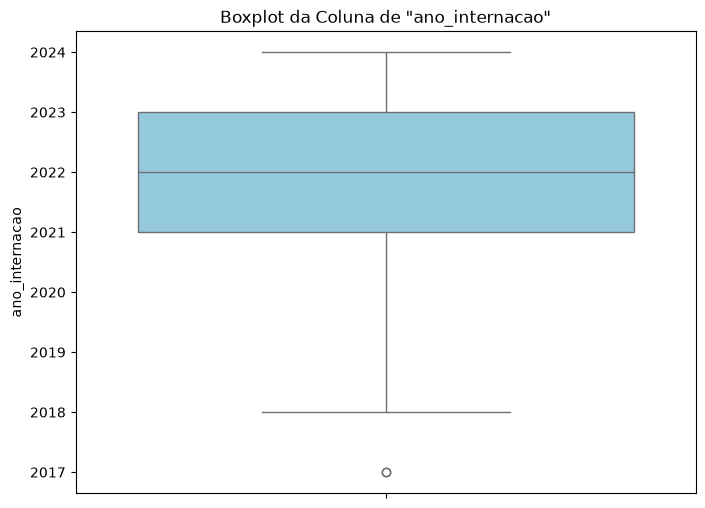

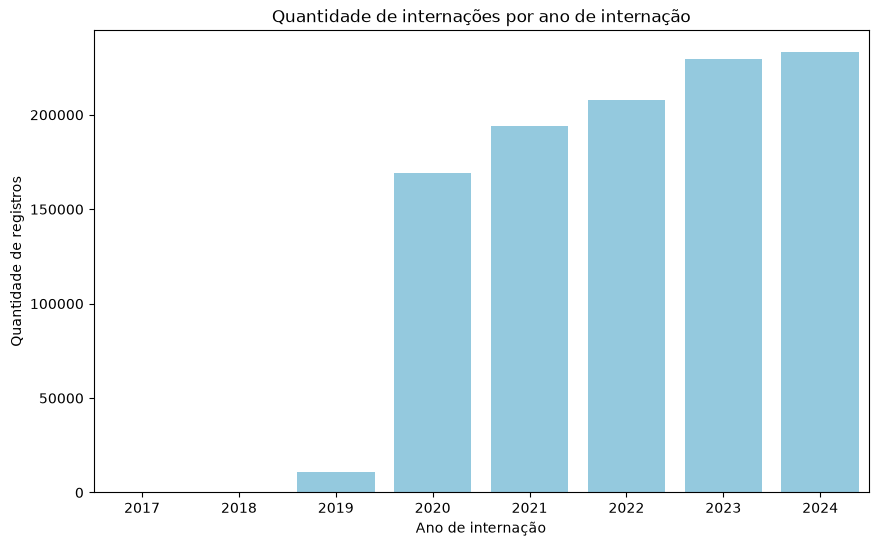

In [27]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_modelo, y='ano_internacao', color='skyblue')
plt.title('Boxplot da Coluna de "ano_internacao"')
plt.ylabel('ano_internacao')

plt.figure(figsize=(10, 6))
sns.countplot(data=df_modelo, x="ano_internacao", color='skyblue')
plt.title("Quantidade de internações por ano de internação")
plt.xlabel("Ano de internação")
plt.ylabel("Quantidade de registros")

plt.show()

pelo com base nos graficos podemos observar que a maior parte da nossa base esta concentrada entre 2020 e 2024, isso faz sentido pois foi o intervalo que selecionamos no site do datasus. podemos observar tambem que temos registros anteriores ao intervalo selecionado, especialmente 2019 e alguns casos isolados em 2017 e 2018. isso provavelmente se deve a presença de internações iniciadas antes do intervalo selecionado. devemos ter cautela ao analisar os intervalos anteriores a  2020 pois não representam o valor geralm da base. Talves seja interessante cortarmos os dados anteriores a 2020 para nossa analise, sendo necessario caso opte por fazer isso, dropar a variavel alvo internação_prolongada, e cria-la de novo, pois a mesma foi criada com base no 3 quartil em cima da base filtrada

agora, mes_internacao

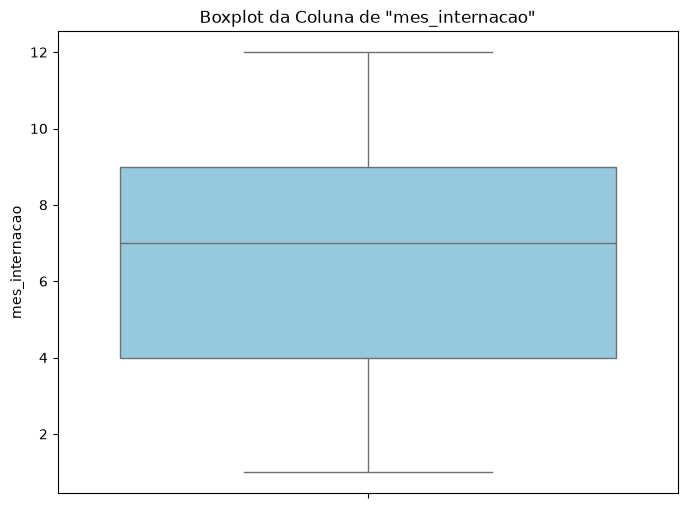

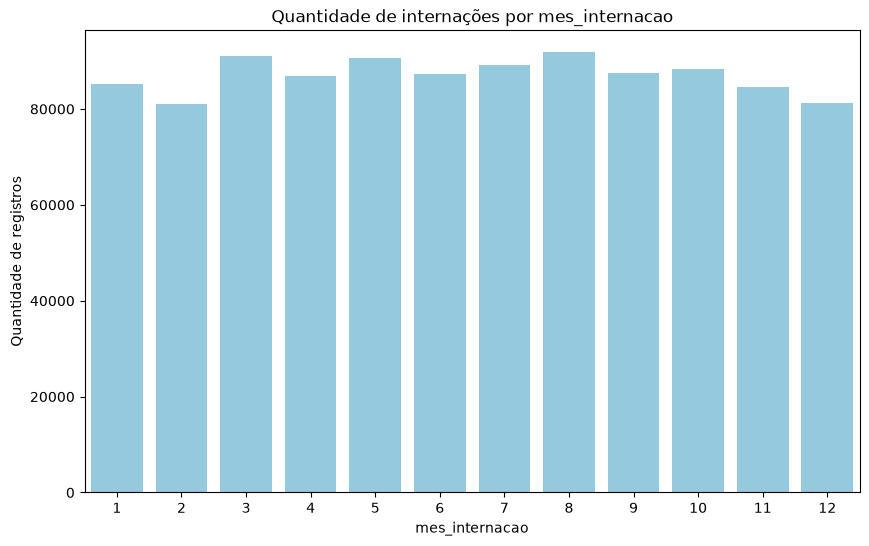

In [28]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_modelo, y='mes_internacao', color='skyblue')
plt.title('Boxplot da Coluna de "mes_internacao"')
plt.ylabel('mes_internacao')

plt.figure(figsize=(10, 6))
sns.countplot(data=df_modelo, x="mes_internacao", color='skyblue')
plt.title("Quantidade de internações por mes_internacao")
plt.xlabel("mes_internacao")
plt.ylabel("Quantidade de registros")

plt.show()

Podemos observar que a variavel está dentro do intervalo so 1 a 12, ou seja, apos a criarmos, ela não apresentou meses invalidos ou inconsistentes. Podemos observar que as internações estão distribuidas de forma relativamente equilibrada ao longo dos meses havendo pequenas variações entre os meses, no entanto na visualização geral não tem uma concentração extrema em apenas um mês. talvez posteriormente  seria interessante analisar a variavel comparando com o ano, para ver como as ocorrencias por mês se distribuem em um ano especifico

agora, idade_anos

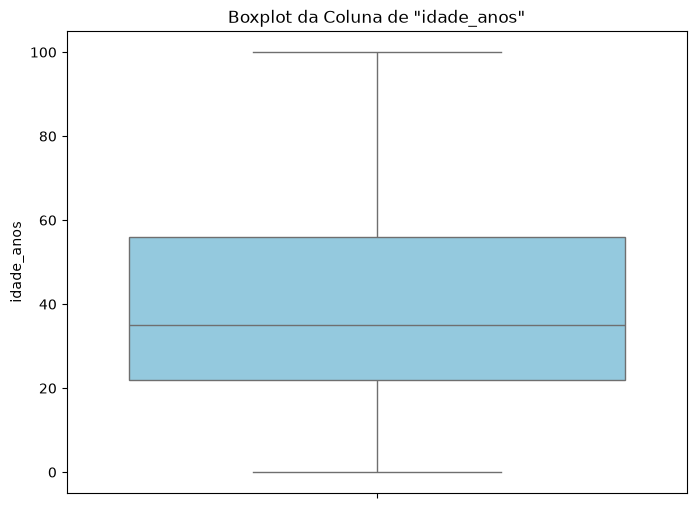

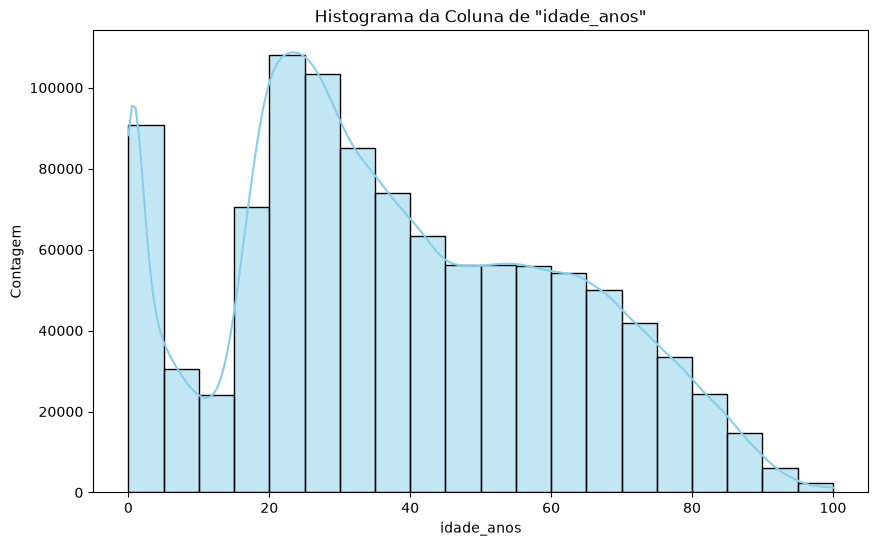

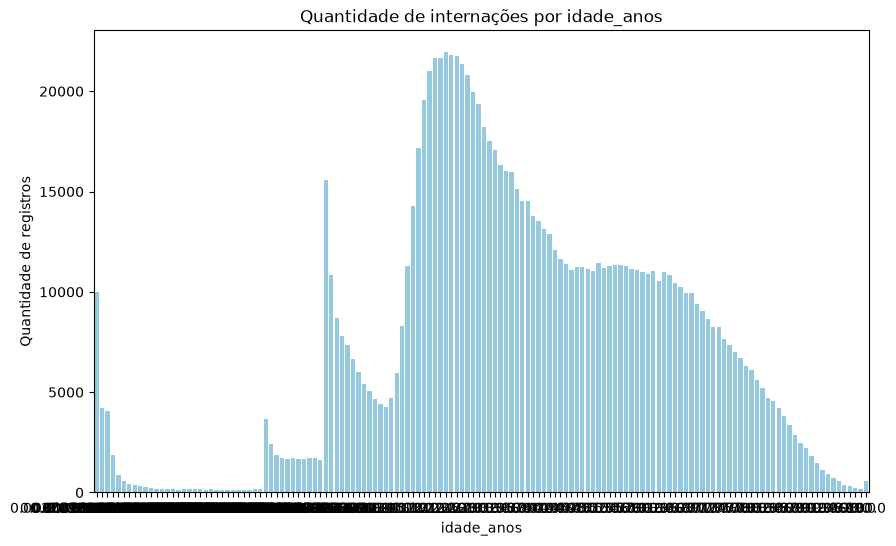

In [29]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_modelo, y='idade_anos', color='skyblue')
plt.title('Boxplot da Coluna de "idade_anos"')
plt.ylabel('idade_anos')

plt.figure(figsize=(10, 6))
sns.histplot(data=df_modelo, x='idade_anos', bins=20, kde=True, color='skyblue')
plt.title('Histograma da Coluna de "idade_anos"')
plt.xlabel('idade_anos')
plt.ylabel('Contagem')

plt.figure(figsize=(10, 6))
sns.countplot(data=df_modelo, x="idade_anos", color='skyblue')
plt.title("Quantidade de internações por idade_anos")
plt.xlabel("idade_anos")
plt.ylabel("Quantidade de registros")

plt.show()

podemos observar que os valores de idade estão entre 0 a 100 anos, não havendo a presença de valores negativos ou idade acima do limite na base, nos mostrando que a conversão da idade foi realizada corretamente. a mediana está la por volta dos 35 anos e os registros se concentram entre 22 e 56 anos. podemos observar que a distribuição não é uniforme, tendo uma concentração entre os recem nascidos e crianças pequenas, seguindo então por internações de jovens adultos e os de meia idade, tendo uma queda nas faixas etarias mais avançadas.

agora, internacao_prolongada

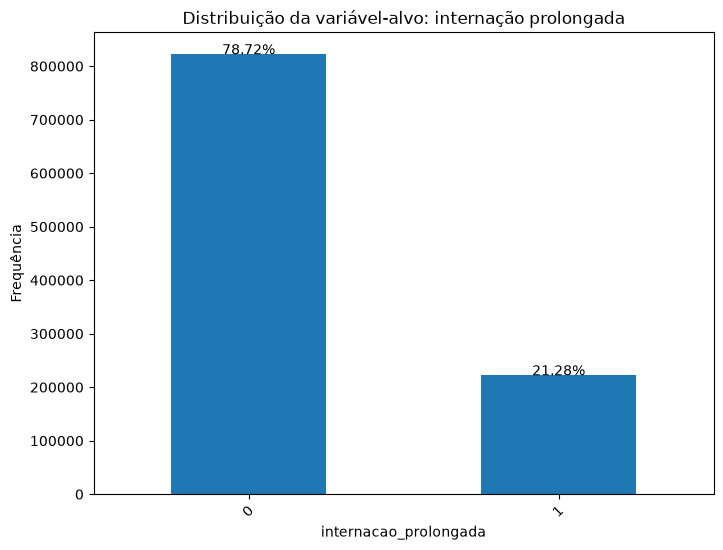

internacao_prolongada
0    78.717824
1    21.282176
Name: count, dtype: float64


In [30]:
contagem_internacao = df_modelo['internacao_prolongada'].value_counts()
porcentagem_internacao = (contagem_internacao / contagem_internacao.sum()) * 100

plt.figure(figsize=(8, 6))

ax = contagem_internacao.plot(kind='bar')

for i, v in enumerate(contagem_internacao):
    ax.text(i, v + 1, f'{porcentagem_internacao.iloc[i]:.2f}%', ha='center')
plt.title('Distribuição da variável-alvo: internação prolongada')
plt.xlabel('internacao_prolongada')
plt.ylabel('Frequência')
plt.xticks(rotation=45)

plt.show()
print(porcentagem_internacao)

o grafico mostra que aproximadamente 78,72% dos registros foram classificados como internações não prolongadas, já 21,28% foram classificados como internações prolongadas. isso nos mostra que nossa base tem um desbalanceamentoentre as classes com predominancia da classe 0. Sendo esse comportamento esperado já que a variavel foi definida a partir do terceiro quartil ou seja a partir do percentil 75 da permanencia hospitalar.

Isso é interessante pois acuracia isolada nesse caso não é suficiente para avaliar o desempenho do modelo. Sendo o objetivo principal identificar internações com risco de permanencia prolongada, metricas como recall, precision, f1-score e matriz de confusão são mais adequadas para avaliar a capacidade do modelo de reconhecer corretamente a classe 1

Agora valiamos as variaveis categoricas, verificando a distribuição delas e tirando insights

Vamos começar por MUNIC_RES

In [31]:
df_modelo["MUNIC_RES"].nunique()

2200

In [32]:
df_modelo["MUNIC_RES"].value_counts().head(10)

MUNIC_RES
510340    135317
510760     90088
510840     72242
510790     38238
510250     32418
510525     29158
510704     25697
510795     24715
510792     24247
510675     18651
Name: count, dtype: int64

Podemos observar que a variavel possui 2.200 valores distintos, com muitos municipios diferentes na base. a contagem dos valores mostra que alguns municipios concentram um volume maior de registros que os demais, nos indicando uma distribuição de municipios de residencia desbalanceada, ou seja a maior concentração de registros está em poucos municipios enquanto muitos outros provavelmente possuem baixo numero de registros

Vamos criar uma tabela de frequencia, para observar a quantidade de registros, o percentual que cada municipio representa na base e o percentual acumulado

In [33]:
freq_munic_res = (
    df_modelo["MUNIC_RES"]
    .value_counts()
    .reset_index()
)

freq_munic_res.columns = ["MUNIC_RES", "qtd_registros"]

freq_munic_res["perc_registros"] = (
    freq_munic_res["qtd_registros"] / len(df_modelo) * 100
).round(2)

freq_munic_res["perc_acumulado"] = (
    freq_munic_res["perc_registros"].cumsum()
).round(2)

freq_munic_res.head(20) # Vamos observar os 20 primeiros

,MUNIC_RES,qtd_registros,perc_registros,perc_acumulado
0,510340,135317,12.95,12.95
1,510760,90088,8.62,21.57
2,510840,72242,6.92,28.49
3,510790,38238,3.66,32.15
4,510250,32418,3.10,35.25
5,510525,29158,2.79,38.04
6,510704,25697,2.46,40.50
7,510795,24715,2.37,42.87
8,510792,24247,2.32,45.19
9,510675,18651,1.79,46.98


Vemos que na tabela de frequencia o municipio mais frequente representa quase 13% dos registros, se somarmos os 3 mais frequentes ficamos com cerca de 28,49% na base, e os 20 municipios com maior numero de registros concentram aproximadamente 60,42% das internações.
Isso nos mostra uma forte concentração em um conjunto pequeno de municipios, tendo tambem uma grande quantidade de municipios com menor participação, nos intregando que municipios com muitos registros podem ter padrões mais estaveis, enquanto municipios com poucos registros podem gerar estimativas menos confiaveis

Como analisamos os 20 primeiros municipios com maior quantidade de registros vamos printar em um grafico para ter uma melhor visualização

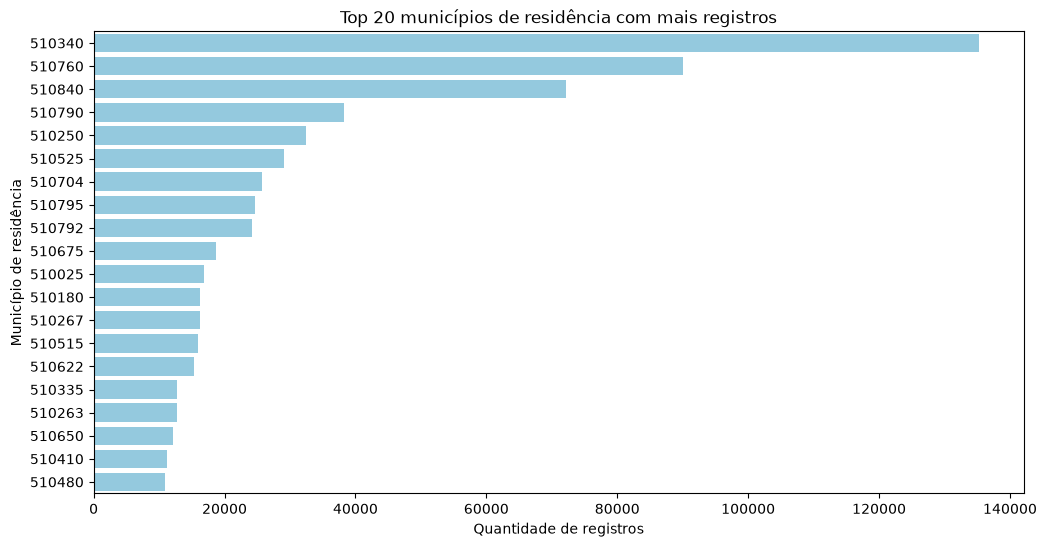

In [34]:
top_municipios = freq_munic_res.head(20)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_municipios,
    x="qtd_registros",
    y="MUNIC_RES",
    color="skyblue"
)

plt.title("Top 20 municípios de residência com mais registros")
plt.xlabel("Quantidade de registros")
plt.ylabel("Município de residência")
plt.show()

O municipio 510340 (Cuiabá), aparece com o volume muito superior aos demais, provavelmente por ser a capital, seguido por 510760 (Rondonópolis) e Várzea Grande, se observando uma quueda progressiva na quantidade de registros, em uma distribuição assimetrica

isso nos mostra que MUNIC_RES é uma variavel relevante, capturando diferenças regionais relacionadas ao perfil populacional e acesso ao serviço de saude dos pacientes. porem por possuir alta cardinalidade, seria uma boa avaliar como agrupamento de municipios raros em uma categoria propia, como "outros" por exemplo, ou uma codificação adequada como OneHotEncoder com tratamento para as categorias desconhecidas

agora vamos analisar MUNIC_MOV, que representa o municipio que ocorreu a internação

In [35]:
df_modelo["MUNIC_MOV"].nunique()

81

In [36]:
df_modelo["MUNIC_MOV"].value_counts().head(10)

MUNIC_MOV
510340    222125
510760    128230
510840     58588
510250     55867
510790     43991
510792     35408
510525     28466
510020     24291
510704     24231
510025     23309
Name: count, dtype: int64

ela possui 81 valores distintos, tendo uma menor cardinalidade que MUNIC_RES que representa o municipio do paciente, isso se deve ao fato de pessoas se moverem entre os municipios dentro do propio estado para usarem hospitais de outro municipio, ou estavam no municipio em questão quando precisaram de atendimento no municipio que estavam visitando, sendo o mesmo aplicavel a pessoas de outros estados ou estrangeiras.

A contagem dos valores mais frequentes deixa evidente que alguns municipiosconcentram grande parte das internações, sendo 510340 (Cuiaba) o municipio com mais frequente, muito provavelmente por ser a capital do estado.

isso nos mostra que grande parte das internações ocorre em municipios centrais que alem de terem maior população muito provavelmente tem maior quantidade de leitos e investimento de recursos publicos, porem não podemos afirmar ja que ai necessitariamos de outros dados para aferir essa informação, então tudo que podemos dizer é que provavelmente esses municipios agem como polos de atendimento hospitalar.

In [37]:
freq_munic_mov = (
    df_modelo["MUNIC_MOV"]
    .value_counts()
    .reset_index()
)

freq_munic_mov.columns = ["MUNIC_MOV", "qtd_registros"]

freq_munic_mov["perc_registros"] = (
    freq_munic_mov["qtd_registros"] / len(df_modelo) * 100
).round(2)

freq_munic_mov["perc_acumulado"] = (
    freq_munic_mov["perc_registros"].cumsum()
).round(2)

freq_munic_mov.head(20) # Vamos observar os 20 primeiros

,MUNIC_MOV,qtd_registros,perc_registros,perc_acumulado
0,510340,222125,21.26,21.26
1,510760,128230,12.28,33.54
2,510840,58588,5.61,39.15
3,510250,55867,5.35,44.50
4,510790,43991,4.21,48.71
5,510792,35408,3.39,52.10
6,510525,28466,2.72,54.82
7,510020,24291,2.33,57.15
8,510704,24231,2.32,59.47
9,510025,23309,2.23,61.70


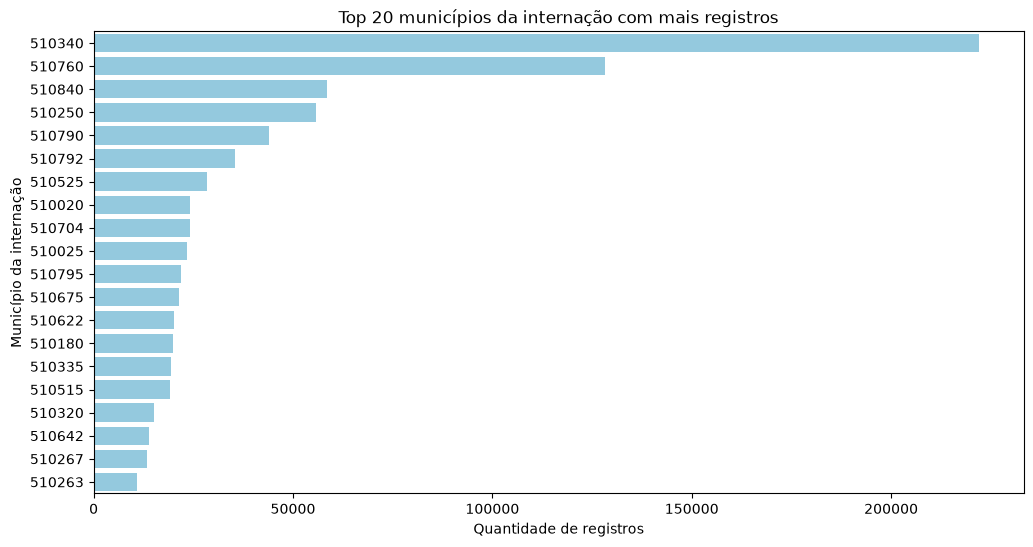

In [39]:
top_municipios_mov = freq_munic_mov.head(20)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_municipios_mov,
    x="qtd_registros",
    y="MUNIC_MOV",
    color="skyblue"
)

plt.title("Top 20 municípios da internação com mais registros")
plt.xlabel("Quantidade de registros")
plt.ylabel("Município da internação")
plt.show()

observando o grafico de barras e a tabela de frequencia, podemos observar que os 20 municipios onde ocorreram o maior numero de internações reforçam a concentração de registros em poucos municipios, demostrando que a rede hospitalar possui centralização em alguns municipios tendo uma queda progressiva apos os primeiros colocados.

isso nos indica que seria uma boa ideia manter MUNIC_MOV, ja que essa informação se associa a estrutura disponivel ao perfil dos hospitais, a complexidade dos casos e ao fluxo regional de pacientes, sendo mais facil de tratar que MUNIC_RES

agora vamos para a CNES que é o codigo que representa o hospital onde ocorreu a internação

In [40]:
df_modelo["CNES"].nunique()

118

In [41]:
df_modelo["CNES"].value_counts().head(10)

CNES
2396866    64302
2311682    59411
9209352    42413
2391635    40359
2604434    37843
2659107    37654
2795655    35146
2534460    30535
2767953    28466
2795671    26298
Name: count, dtype: int64

a variavel possui 118 registros distintos e a contagem mais frequente mostra que alguns estabelecimentos concentram um maior volume de internações

In [ ]:
freq_cnes = (
    df_modelo["CNES"]
    .value_counts()
    .reset_index()
)

freq_cnes.columns = ["CNES", "qtd_registros"]

freq_cnes["perc_registros"] = (
    freq_cnes["qtd_registros"] / len(df_modelo) * 100
).round(2)

freq_cnes["perc_acumulado"] = (
    freq_cnes["perc_registros"].cumsum()
).round(2)

freq_cnes.head(20) # Vamos observar os 20 primeiros

,CNES,qtd_registros,perc_registros,perc_acumulado
0,2396866,64302,6.16,6.16
1,2311682,59411,5.69,11.85
2,9209352,42413,4.06,15.91
3,2391635,40359,3.86,19.77
4,2604434,37843,3.62,23.39
5,2659107,37654,3.60,26.99
6,2795655,35146,3.36,30.35
7,2534460,30535,2.92,33.27
8,2767953,28466,2.72,35.99
9,2795671,26298,2.52,38.51


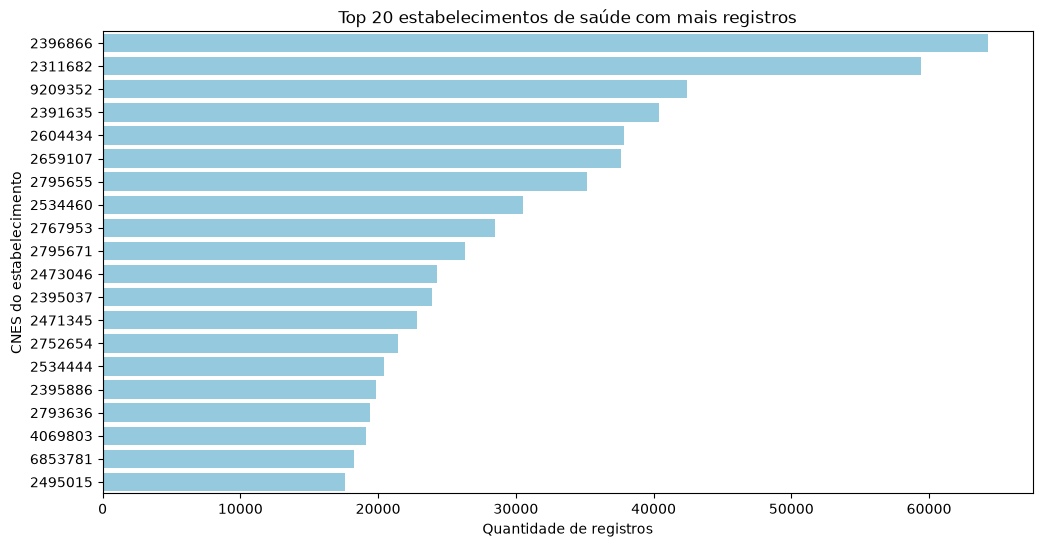

In [ ]:
top_cnes = freq_cnes.head(20)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_cnes,
    x="qtd_registros",
    y="CNES",
    color="skyblue"
)

plt.title("Top 20 estabelecimentos de saúde com mais registros")
plt.xlabel("Quantidade de registros")
plt.ylabel("CNES do estabelecimento")
plt.show()

o grafico e a tabela de frequencia doa 20 estabelecimentos de saude com maior quantidade de registros nos reforça a ideia que alguns CNES concentram mair volume de internações, sendo destaques 2396866 (Santa Casa de Rondonópolis) e 2311682 (Hospital Santa Helena).

a queda na concentração é gradual e indica que a base não depende exclusivamente de uma unidade hospitalar, permitindo que o modelo aprenda padrões associados a diferentes perfis de hospitais.

essa variavel é importante de se manterpor representar o local especifico do atendimento, se relacionando assim a estrutura hospitalar, disponibilidade de leitos, complexidade dos serviços, especialidades atendidas e perfil dos pacientes

agora vamos para a ESPEC que representa a especialidade do leito

In [47]:
df_modelo["ESPEC"].nunique()

8

In [63]:
df_modelo["ESPEC"].value_counts()

ESPEC
3    378060
1    352822
2    204736
7     92992
5     15539
4       432
9        48
6         1
Name: count, dtype: int64

Ela possui 8 categorias distintas o que facilita seu uso posterior na modelagem, sendo a categoria 3 (Clínica médica) a mais frequente seguida respectivamente pela 1 (Cirurgia) e pela 2 (Obstetrícia).

In [61]:
freq_espec = (
    df_modelo["ESPEC"]
    .value_counts()
    .reset_index()
)

freq_espec.columns = ["ESPEC", "qtd_registros"]

freq_espec["perc_registros"] = (
    freq_espec["qtd_registros"] / len(df_modelo) * 100
).round(2)

freq_espec["perc_acumulado"] = (
    freq_espec["perc_registros"].cumsum()
).round(2)

freq_espec

,ESPEC,qtd_registros,perc_registros,perc_acumulado
0,3,378060,36.19,36.19
1,1,352822,33.77,69.96
2,2,204736,19.60,89.56
3,7,92992,8.90,98.46
4,5,15539,1.49,99.95
5,4,432,0.04,99.99
6,9,48,0.00,99.99
7,6,1,0.00,99.99


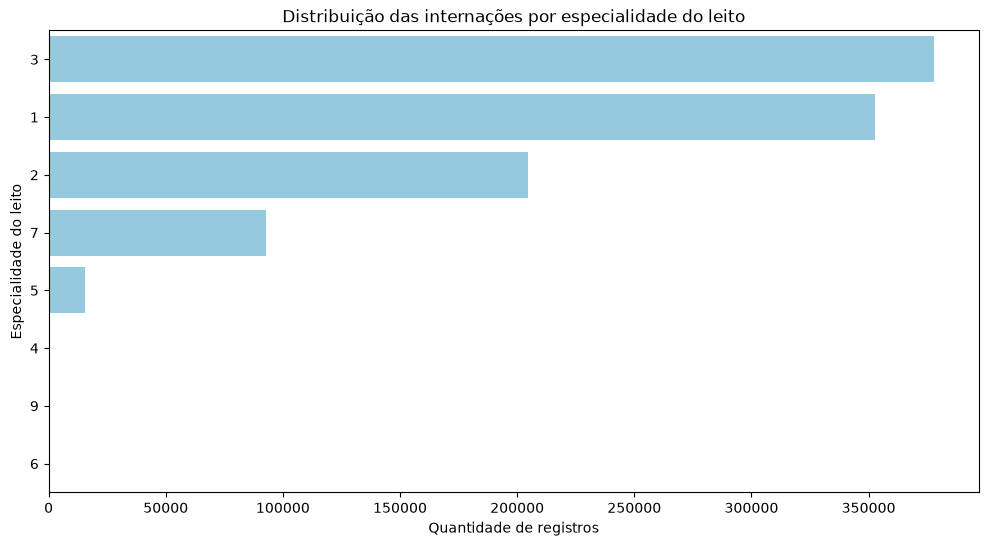

In [62]:
top_espec = freq_espec

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_espec,
    x="qtd_registros",
    y="ESPEC",
    color="skyblue"
)

plt.title("Distribuição das internações por especialidade do leito")
plt.xlabel("Quantidade de registros")
plt.ylabel("Especialidade do leito")
plt.show()

A tabela de frequencia e o grafivo de barras nos mostra a distribuição dos registros por especialidade, sendo como podemos observar uma variavel categorica importante para o projeto, pois pode ajudar o modelo a diferenciar perfis de internação com maior ou menor risco de permanencia prolongada. como podemos observar a depender da especialidade o tempo de permanencia sera distinto dependendo assim da complexidade do atendimento e o tipo de cuidado necessario

agora vamos para CAR_INT que representa o carater da internação ou seja, a forma de entrada ou motivo administrativo da internação

In [52]:
df_modelo["CAR_INT"].nunique()

6

In [59]:
df_modelo["CAR_INT"].value_counts()

CAR_INT
2    862135
1    181325
5      1046
3        67
6        49
4         8
Name: count, dtype: int64

Ela possui 6 categorias distintas, sendo a maior concentração no codigo 2

In [58]:
freq_car_int = (
    df_modelo["CAR_INT"]
    .value_counts()
    .reset_index()
)

freq_car_int.columns = ["CAR_INT", "qtd_registros"]

freq_car_int["perc_registros"] = (
    freq_car_int["qtd_registros"] / len(df_modelo) * 100
).round(2)

freq_car_int["perc_acumulado"] = (
    freq_car_int["perc_registros"].cumsum()
).round(2)

freq_car_int

,CAR_INT,qtd_registros,perc_registros,perc_acumulado
0,2,862135,82.53,82.53
1,1,181325,17.36,99.89
2,5,1046,0.10,99.99
3,3,67,0.01,100.00
4,6,49,0.00,100.00
5,4,8,0.00,100.00


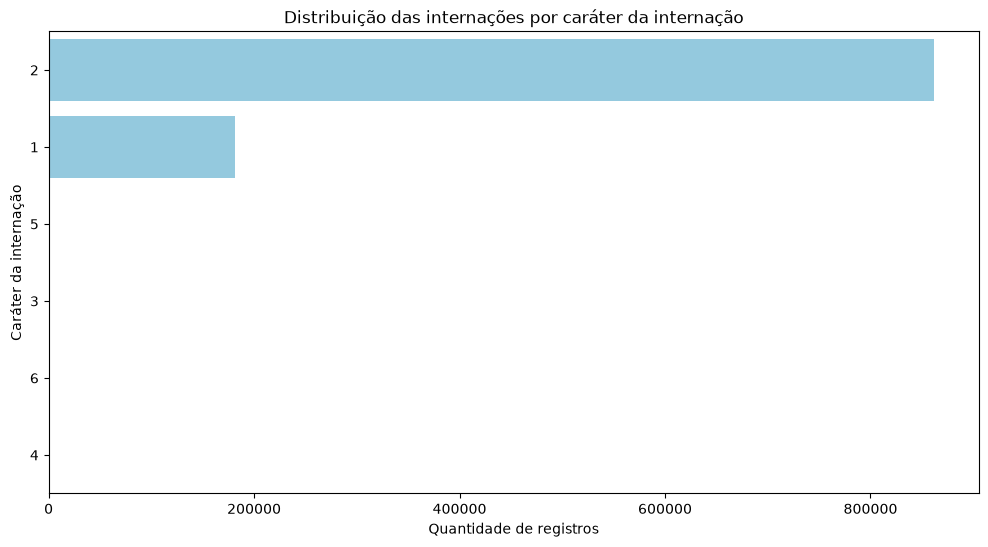

In [57]:
top_car_int = freq_car_int

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_car_int,
    x="qtd_registros",
    y="CAR_INT",
    color="skyblue"
)

plt.title("Distribuição das internações por caráter da internação")
plt.xlabel("Quantidade de registros")
plt.ylabel("Caráter da internação")
plt.show()

A tabela de frequencia e o grafico de barras nos mostra a distribuição dos registros por carater de internação e a pedrominancia do codigo 2, mostrando que a variavel CAR_INT é altamente desbalanceada entre suas categoriasporem ainda é util por representar uma informação administrativa importante sobre o contexto da internação. Talvez seja interessante posteriormente avaliar se as categorias com pouquissimos registros devem ser mantidas ou agrupadas em uma categoria "outros", evitando instabilidade no treinamento

Agora vamos para cid3, criada a partir dos 3 primeiros do cid disponivel no DIAG_PRINC

In [64]:
df_modelo["cid3"].nunique()

1539

In [66]:
df_modelo["cid3"].value_counts().head(20)

cid3
O80    82754
O82    51402
B34    40648
J18    33151
K80    21433
S82    21224
S52    19540
Z30    18266
N39    16035
I50    14541
K40    14515
K35    13236
J15    12649
S42    11154
I64    11110
S72    11043
I21    10926
A41    10562
S06    10063
Z47     9726
Name: count, dtype: int64

Ela possui 1539 categorias distintas mesmo apos o agrupamento do diagnostico principal, isso ja era esperado, pois o SIH/SUS registra internações associadas a diferentes condições clinicas, procedimentos e perfis assistenciais

In [72]:
freq_cid3 = (
    df_modelo["cid3"]
    .value_counts()
    .reset_index()
)

freq_cid3.columns = ["cid3", "qtd_registros"]

freq_cid3["perc_registros"] = (
    freq_cid3["qtd_registros"] / len(df_modelo) * 100
).round(2)

freq_cid3["perc_acumulado"] = (
    freq_cid3["perc_registros"].cumsum()
).round(2)

freq_cid3.head(20)

,cid3,qtd_registros,perc_registros,perc_acumulado
0,O80,82754,7.92,7.92
1,O82,51402,4.92,12.84
2,B34,40648,3.89,16.73
3,J18,33151,3.17,19.90
4,K80,21433,2.05,21.95
5,S82,21224,2.03,23.98
6,S52,19540,1.87,25.85
7,Z30,18266,1.75,27.60
8,N39,16035,1.53,29.13
9,I50,14541,1.39,30.52


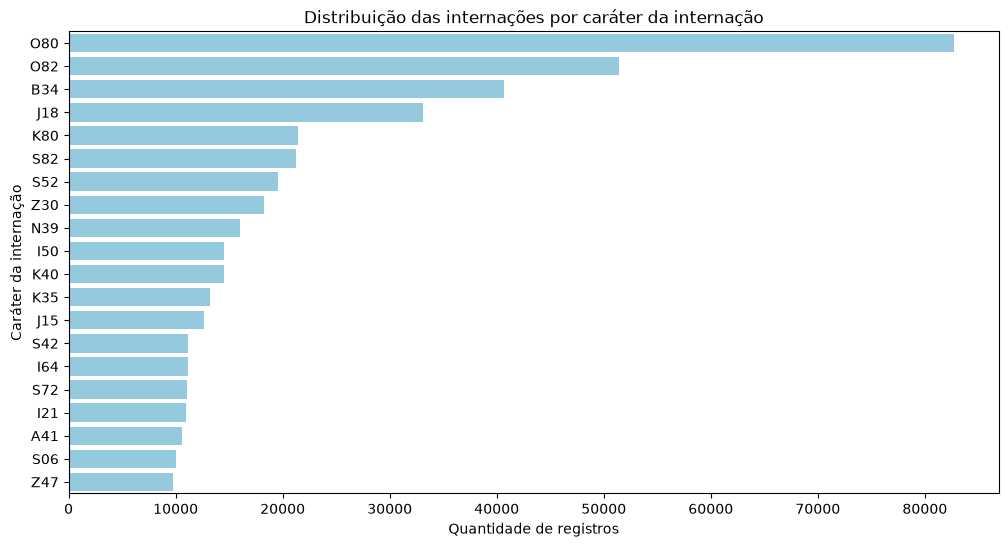

In [73]:
top_cid3 = freq_cid3.head(20)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_cid3,
    x="qtd_registros",
    y="cid3",
    color="skyblue"
)

plt.title("Distribuição das internações por caráter da internação")
plt.xlabel("Quantidade de registros")
plt.ylabel("Caráter da internação")
plt.show()

Analisando a tabela de frequencia e o grafico de barras, podemos observar que alguns diagnosticos concentram maior volume de internações, se mostrando uma das mais importantes, pois o diagnosticoprincipal estaria diretamente relacionado ao tipo de internação, complexidade clinica, procedimento necessario e ao tempo esperado de permanencia. devido a alta cardinalidade pode ser necessario avaliar estrategias de tratamento, como codificação com OneHotEncoder,talvez o agrupamento de diagnosticos raros em uma categoria "outros", ou comparação entre modelos com e sem agrupamento adicional

agora vamos analisar grupo_procedimento que foi criada a partir dos dois primeiros digitos da variavel PROC_COLIC que representa os procedimentos solicitados

In [87]:
df_modelo["grupo_procedimento"].nunique()

4

In [88]:
df_modelo["grupo_procedimento"].value_counts()

grupo_procedimento
03    602664
04    441497
02       393
05        76
Name: count, dtype: int64

Avariavel possui 4 categorias distintas e que os grupos 3 e 4 concentram praticamente todos os registros da base, enquanto os grupos 2 e 5 aparecem com volume muito reduzido.

In [89]:
freq_grupo_procedimento = (
    df_modelo["grupo_procedimento"]
    .value_counts()
    .reset_index()
)

freq_grupo_procedimento.columns = ["grupo_procedimento", "qtd_registros"]

freq_grupo_procedimento["perc_registros"] = (
    freq_grupo_procedimento["qtd_registros"] / len(df_modelo) * 100
).round(2)

freq_grupo_procedimento["perc_acumulado"] = (
    freq_grupo_procedimento["perc_registros"].cumsum()
).round(2)

freq_grupo_procedimento

,grupo_procedimento,qtd_registros,perc_registros,perc_acumulado
0,03,602664,57.69,57.69
1,04,441497,42.26,99.95
2,02,393,0.04,99.99
3,05,76,0.01,100.00


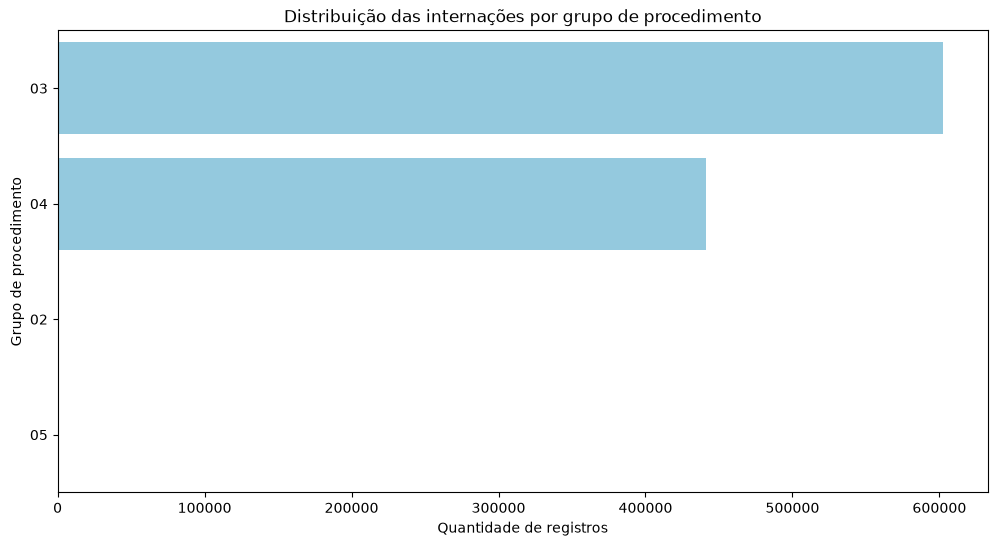

In [91]:
top_grupo_procedimento = freq_grupo_procedimento

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_grupo_procedimento,
    x="qtd_registros",
    y="grupo_procedimento",
    color="skyblue"
)

plt.title("Distribuição das internações por grupo de procedimento")
plt.xlabel("Quantidade de registros")
plt.ylabel("Grupo de procedimento")
plt.show()

observando a tabela de frequencia e o grafico de barras podemos observar que o perfil dos procedimentos é dominado por grupos, podendo influenciar o comportamento do modelo, apesar disso é uma variavel util, representando uma informação assistencial importante sobre o tipo de procedimento solicitado.

como os grupos minoritarios possuem poucos registros, pode ser interessante avaliar se eles deveriam ser mantidos separadamente ou agrupados em uma categoria, como "outros" por exemplo

vamos para COMPLEX que representa a complexidade associada ao procedimento ou a internação

In [79]:
df_modelo["COMPLEX"].nunique()

2

In [80]:
df_modelo["COMPLEX"].value_counts()

COMPLEX
2    1005736
3      38894
Name: count, dtype: int64

A variavel possui apenas duas categorias, 2 e 3 sendo 2 a predominante, ou seja a maior parte das internações está concentrada em um unico nivel de complexidade

In [81]:
freq_complex = (
    df_modelo["COMPLEX"]
    .value_counts()
    .reset_index()
)

freq_complex.columns = ["COMPLEX", "qtd_registros"]

freq_complex["perc_registros"] = (
    freq_complex["qtd_registros"] / len(df_modelo) * 100
).round(2)

freq_complex["perc_acumulado"] = (
    freq_complex["perc_registros"].cumsum()
).round(2)

freq_complex

,COMPLEX,qtd_registros,perc_registros,perc_acumulado
0,2,1005736,96.28,96.28
1,3,38894,3.72,100.00


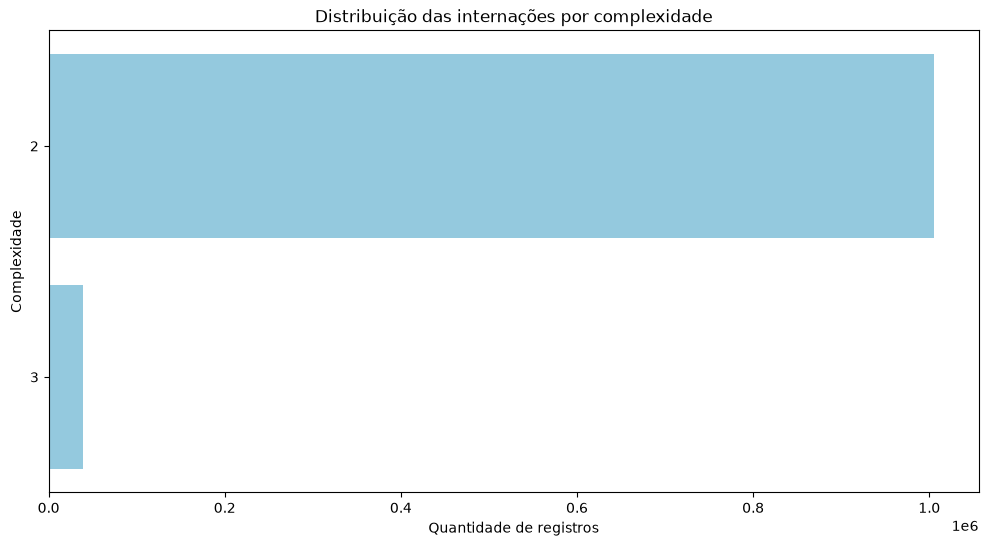

In [92]:
top_complex = freq_complex

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_complex,
    x="qtd_registros",
    y="COMPLEX",
    color="skyblue"
)

plt.title("Distribuição das internações por complexidade")
plt.xlabel("Quantidade de registros")
plt.ylabel("Complexidade")
plt.show()

Analisando a tabela de frequencia e o grafico de barras podemos observar que a complexidade não está distribuida de forma equilibrada na base, apesar disso ela ainda pode ajudar o modelo a diferenciar perfis de internação com diferentes niveis de complexidade

Apesar da baixa variedade de categorias, a variavel pode ser relevante para o modelo pois a complexidade do atendimento pode estar relacionada ao tempo de permanencia hospitalar

apesar disso, por existir grande concentração uma única categoria, o impacto dessa variavel pode ser limitado no modelo, seu valor preditivo necessita de ser avaliado em conjunto com outras variaveis